# importation des librairies

In [1]:
# importation des librairies
import pandas as pd
import numpy  as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Prétraitement
from sklearn.model_selection import train_test_split,cross_val_score,GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler,LabelEncoder,OrdinalEncoder

# Modèles
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

#Evaluation
from sklearn.metrics import(accuracy_score,classification_report,confusion_matrix,f1_score, precision_score, recall_score)

# Sauvegarde des artefacts
import joblib
import os

# Configuration de l'affichage
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"]=(9, 5)
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Librairies importées avec succès")


Librairies importées avec succès


In [2]:
# Chargement des données
data = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(f"dimensions du dataset :{data.shape[0]} lignes x {data.shape[1]} colonnes")
data.head()

dimensions du dataset :7043 lignes x 21 colonnes


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
# valeurs manquantes
print("Valeurs manquantes par colonne:")
print(data.isnull().sum())
print(f"nTotal de valeurs manquantes : {data.isnull().sum().sum()}")

Valeurs manquantes par colonne:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
nTotal de valeurs manquantes : 0


In [5]:
# recherche des doublons
nb_doublons = data.duplicated().sum()
print(f"Nombre de lignes strictement dupliquée :{nb_doublons}")

Nombre de lignes strictement dupliquée :0


In [6]:
# recherche des valeurs aberrantes catégorielles
num_cols = data.select_dtypes(include="object").columns

data[num_cols].describe().T

C:\Users\solution info\AppData\Local\Temp\ipykernel_10288\786708694.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  num_cols = data.select_dtypes(include="object").columns


,count,unique,top,freq
customerID,7043,7043,7590-VHVEG,1
gender,7043,2,Male,3555
Partner,7043,2,No,3641
Dependents,7043,2,No,4933
PhoneService,7043,2,Yes,6361
MultipleLines,7043,3,No,3390
InternetService,7043,3,Fiber optic,3096
OnlineSecurity,7043,3,No,3498
OnlineBackup,7043,3,No,3088
DeviceProtection,7043,3,No,3095


In [7]:
# recherche des valeurs aberrantes numériques
num_cols = data.select_dtypes(include= 'number').columns

data[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


In [8]:
def detect_outliers(col):
     q1, q3 = data[col].quantile([0.25, 0.75])
     iqr = q3 - q1
     borne_inf, borne_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
     outliers = ((data[col] < borne_inf) | (data[col] > borne_sup)).sum()
     return outliers

cols_continues = ["tenure", "MonthlyCharges"]
for col in cols_continues:
    outliers = detect_outliers(col)
    print(f"{col} - Nombre de valeurs aberrantes : {outliers}")


tenure - Nombre de valeurs aberrantes : 0
MonthlyCharges - Nombre de valeurs aberrantes : 0


# Commentaire général :

  Le dataset ci-dessus est un jeu de données obtenu à partir d'une plateforme très reconnue en ligne **Kaggle** qui nous présente un dataset basé sur la prédiction du taux de résiliation ou de désabonnement des différents types de Clients au sein d'une entreprise de télécoms.
  
  En effet, ce dataset est constitué de `trois types` de données parmi lesquels:`int64, float64` et `object`. On distingue aussi :
  
**- 7043 lignes** numéroté de `0 à 7042` et de **21 colonnes** numéroté de `0 à 20`.

**-  Aucunes valeurs aberrantes**

**- Aucuns Doublons**.

  Bienque ce jeu de données a l'aire d'être parfait, toutefois si l'on s' interresse encore plus, nous constaterons plusieurs anomalies parmi lesquelles :
  
  **- Des Features** avec des types qui ne correspond pas .
  
  **- Les colonnes** qui ne vont pas nous aider et qui potentiellement nous cachent certaines informations.

  **- Des features** qui ont des cases vides

# II- ANALYSE EXPLORATOIRE DE LA VARIABLE CIBLE

**Distribution de la variable cible**

Churn
No     5174
Yes    1869
Name: count, dtype: int64


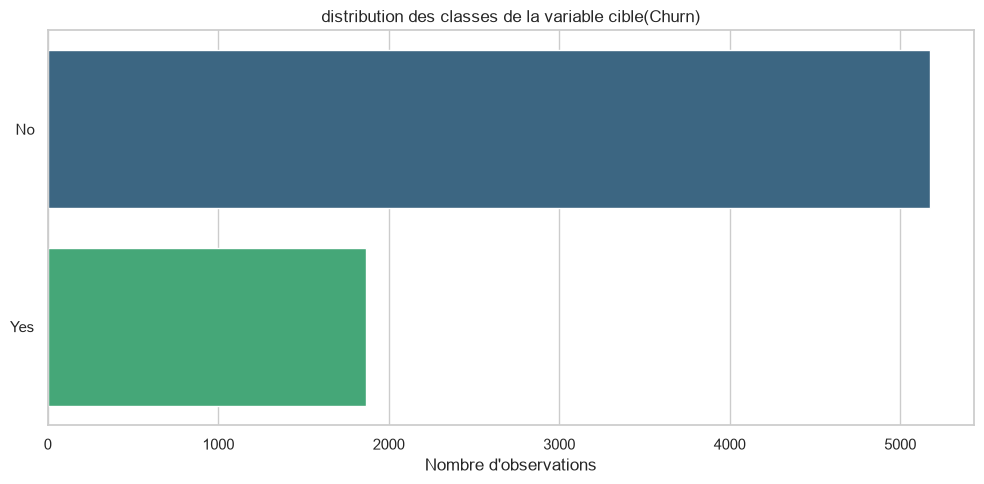

In [9]:
print(data["Churn"].value_counts())

plt.figure(figsize=(10, 5))
order_classes = data["Churn"].value_counts().index
sns.countplot(data=data, y="Churn", order=order_classes, hue="Churn",palette="viridis", legend=False)
plt.title("distribution des classes de la variable cible(Churn)")
plt.xlabel("Nombre d'observations")
plt.ylabel("")
plt.tight_layout()
plt.show()

 **Vérification de l'équilibre de la variable cible**

In [10]:
data["Churn"].value_counts(normalize = True)*100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

# Commentaire Général :

Lors de la distribution de la variable cible et de la vérification de l'équilibre de la cible, nous remarquons un vaste déséquilibre entre les classes de target ce qui nous pousse donc à se poser la question, Comment faire pour équilibrer cette cible ?

# III- NETTOYAGE DES DONNEES

**copie de travail pour préserver le dataset brut**

In [11]:
df = data.copy()

**Vérification de la cohérence des valeurs (bornes logiques)**

In [12]:
colonnes_numériques =["tenure", "SeniorCitizen", "MonthlyCharges"]
print(" valeurs min/ max des variables numériques :")
print(df[colonnes_numériques].agg(["min","max"]).T)

 valeurs min/ max des variables numériques :
                  min     max
tenure           0.00   72.00
SeniorCitizen    0.00    1.00
MonthlyCharges  18.25  118.75


**Harmonisation des types de données catégorielles ( suppression d'espaces superflus)**

In [13]:
colonnes_catégorielles= df.select_dtypes(include="object").columns
for col in colonnes_catégorielles:
    df[col] = df[col].astype(str).str.strip()

    print("Colonnes catégorielles harmonisées:",colonnes_catégorielles)

C:\Users\solution info\AppData\Local\Temp\ipykernel_10288\3959909719.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  colonnes_catégorielles= df.select_dtypes(include="object").columns


Colonnes catégorielles harmonisées: Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='str')
Colonnes catégorielles harmonisées: Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='str')
Colonnes catégorielles harmonisées: Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
 

**Les catégories déclarées sont-elles toutes exploitable statistiquement**

In [14]:
for col in df.columns:
    #print(df[col].value_counts())
    print(f"{df[col].nunique()} valeurs uniques")

7043 valeurs uniques
2 valeurs uniques
2 valeurs uniques
2 valeurs uniques
2 valeurs uniques
73 valeurs uniques
2 valeurs uniques
3 valeurs uniques
3 valeurs uniques
3 valeurs uniques
3 valeurs uniques
3 valeurs uniques
3 valeurs uniques
3 valeurs uniques
3 valeurs uniques
3 valeurs uniques
2 valeurs uniques
4 valeurs uniques
1585 valeurs uniques
6531 valeurs uniques
2 valeurs uniques


 **Suppression de la colonne CustomerID**

In [15]:
df = df.drop(columns = "customerID")

**Recherche des nouveaux doublons et leur suppression**

In [16]:
new_doublons = df.duplicated().sum()
print(f"Nombre de lignes strictement dupliquée :{new_doublons}")

Nombre de lignes strictement dupliquée :22


In [17]:
avant= df.shape[0]
df = df.drop_duplicates().reset_index(drop = True)
apres = df.shape[0]
print(f"lignes avant suppression des doublons:{avant}")
print(f"lignes après suppression des doublons:{apres}")
print(f"Nombre de lignes supprimées : {avant - apres}")

lignes avant suppression des doublons:7043
lignes après suppression des doublons:7021
Nombre de lignes supprimées : 22


**Changement du type des features**

In [18]:
# comment corriger les types de variables catégorielles codées numériquement ?
df["SeniorCitizen"] = df["SeniorCitizen"].astype("category")

In [19]:
df.describe(include = 'category')

,SeniorCitizen
count,7021
unique,2
top,0
freq,5880


**Suppression des valeurs manquantes et mappage du Total des Charges**

In [20]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

In [21]:
df = df.dropna(subset = ['TotalCharges'])

**Mapping de la variable cible**

In [22]:
df["Churn_bin"] = df["Churn"].map({"Yes":1, "No":0})

In [23]:
df.info()

<class 'pandas.DataFrame'>
Index: 7010 entries, 0 to 7020
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   gender            7010 non-null   str     
 1   SeniorCitizen     7010 non-null   category
 2   Partner           7010 non-null   str     
 3   Dependents        7010 non-null   str     
 4   tenure            7010 non-null   int64   
 5   PhoneService      7010 non-null   str     
 6   MultipleLines     7010 non-null   str     
 7   InternetService   7010 non-null   str     
 8   OnlineSecurity    7010 non-null   str     
 9   OnlineBackup      7010 non-null   str     
 10  DeviceProtection  7010 non-null   str     
 11  TechSupport       7010 non-null   str     
 12  StreamingTV       7010 non-null   str     
 13  StreamingMovies   7010 non-null   str     
 14  Contract          7010 non-null   str     
 15  PaperlessBilling  7010 non-null   str     
 16  PaymentMethod     7010 non-null   str   

In [24]:
def detect_outliers(col):
     q1, q3 = df[col].quantile([0.25, 0.75])
     iqr = q3 - q1
     borne_inf, borne_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
     outliers = ((df[col] < borne_inf) | (df[col] > borne_sup)).sum()
     return outliers
for col in df.select_dtypes(include=[np.number]).columns:
    outliers = detect_outliers(col)
    print(f"{col} - Nombre de valeurs aberrantes : {outliers}")

tenure - Nombre de valeurs aberrantes : 0
MonthlyCharges - Nombre de valeurs aberrantes : 0
TotalCharges - Nombre de valeurs aberrantes : 0
Churn_bin - Nombre de valeurs aberrantes : 0


In [25]:

df.describe().T

,count,mean,std,min,25%,50%,75%,max
tenure,7010.0,32.520399,24.520441,1.00,9.0000,29.000,56.0000,72.00
MonthlyCharges,7010.0,64.888666,30.064769,18.25,35.7500,70.400,89.9000,118.75
TotalCharges,7010.0,2290.353388,2266.820832,18.80,408.3125,1403.875,3807.8375,8684.80
Churn_bin,7010.0,0.264907,0.441315,0.00,0.0000,0.000,1.0000,1.00


# Commentaire Général : 

# III- ANALYSE EXPLORATOIRE ET VISUALISATION PERTINANTE

**Distribution des principales variables**

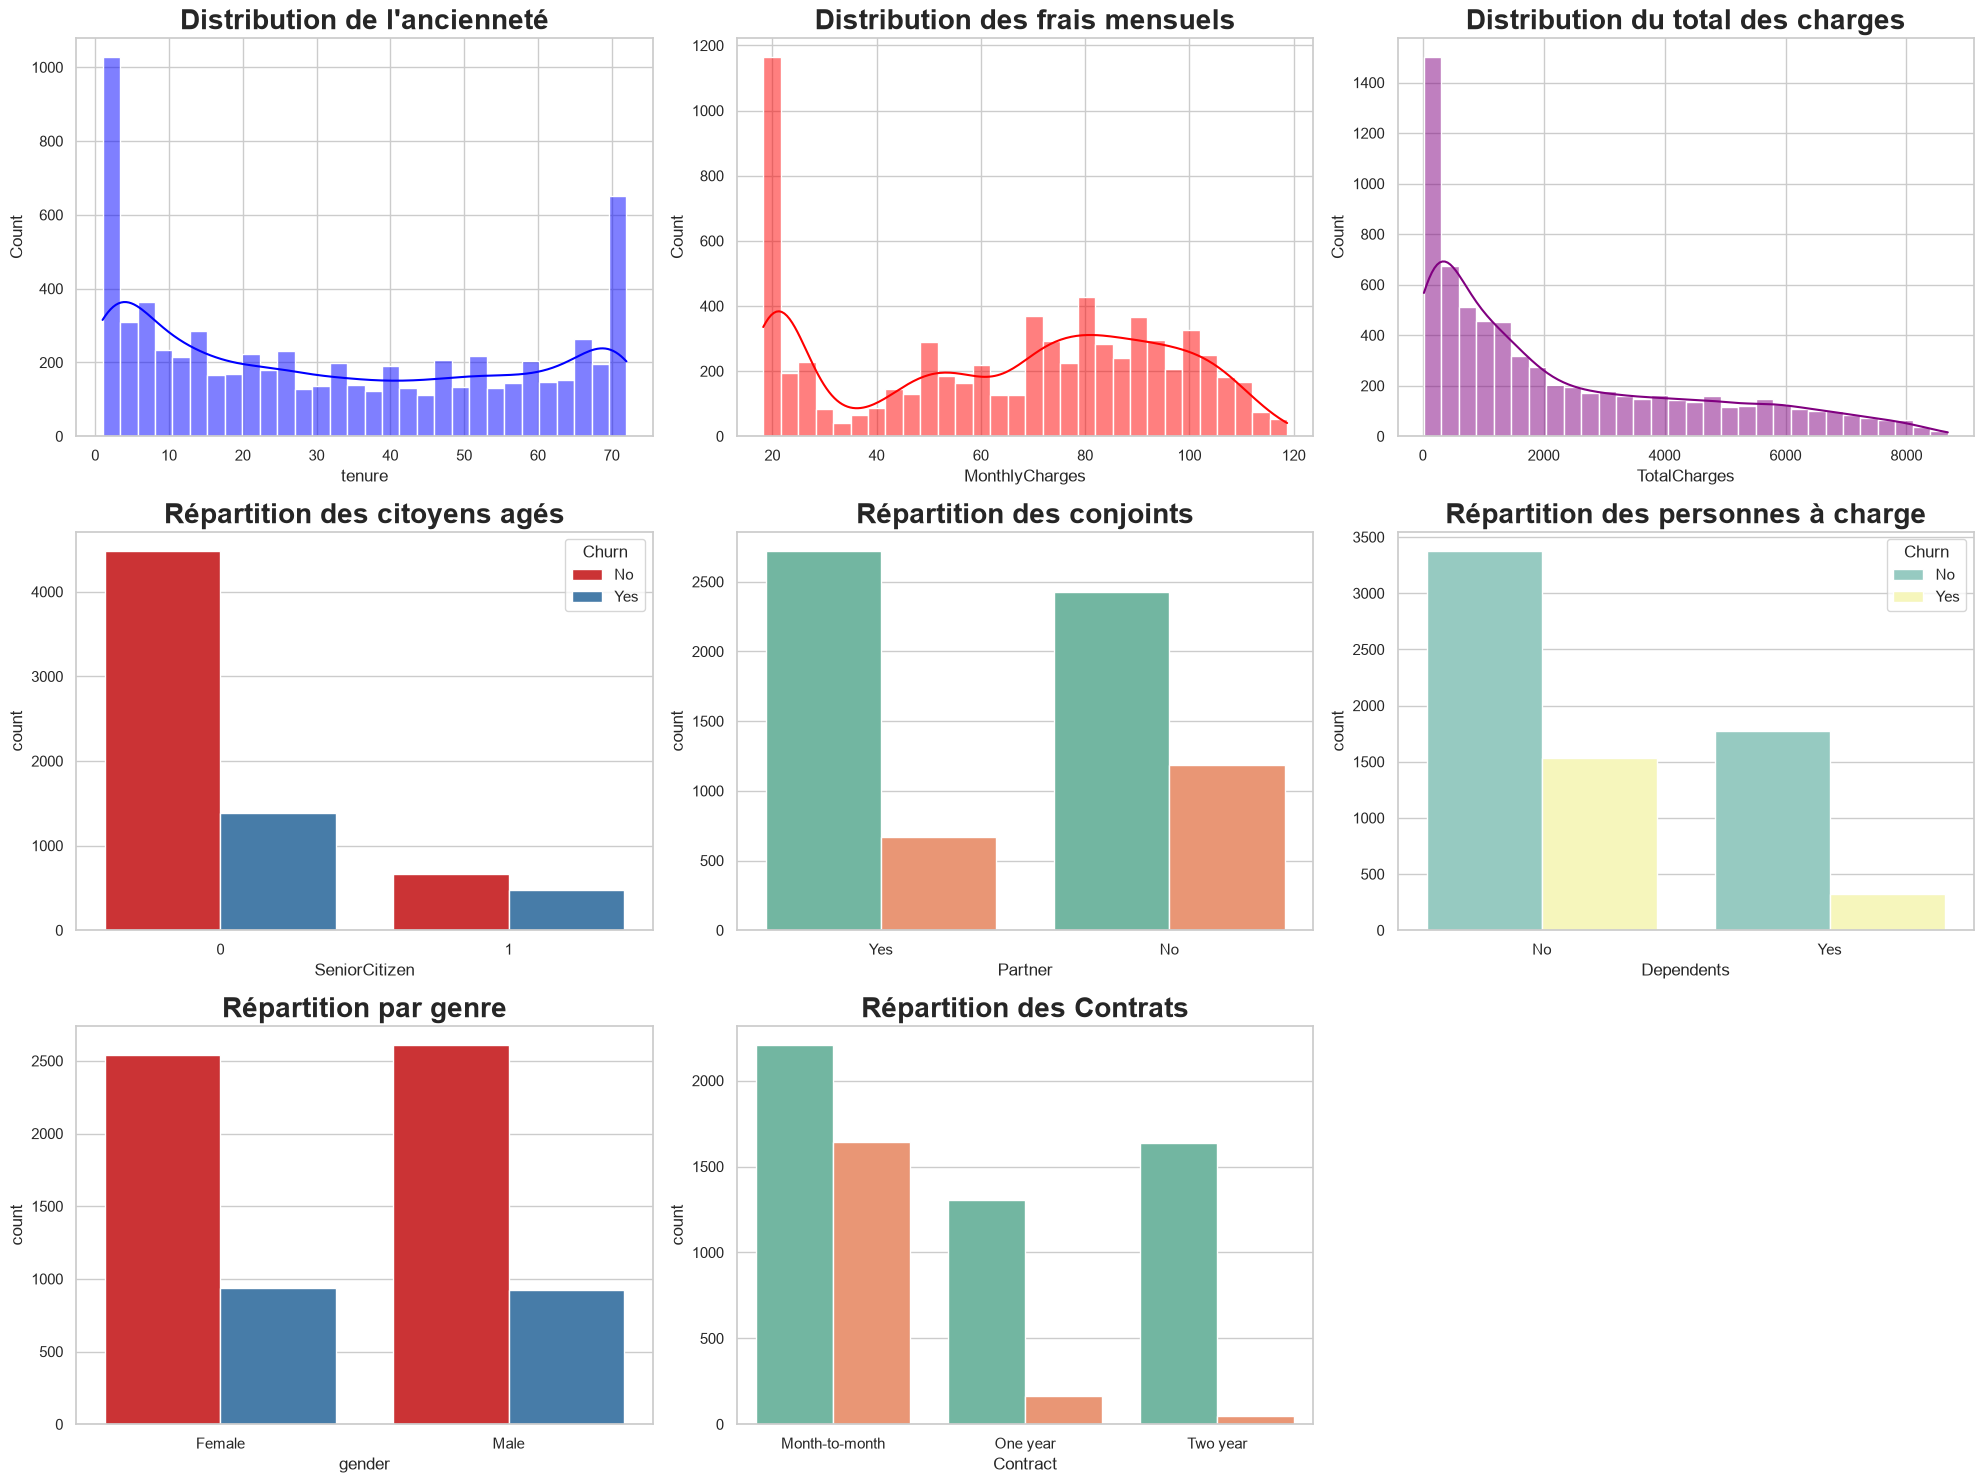

In [26]:
fig, axes = plt.subplots(3, 3, figsize=(20,15))

sns.histplot(df["tenure"], bins=30, kde=True, ax= axes[0,0], color= "blue")
axes[0,0].set_title("Distribution de l'ancienneté", fontweight= 'bold', fontsize = '20' )

sns.histplot(df["MonthlyCharges"], bins=30, kde=True, ax=axes[0,1], color="red")
axes[0,1].set_title("Distribution des frais mensuels",fontweight= 'bold', fontsize = '20') 

sns.histplot(df["TotalCharges"], bins=30, kde=True, ax=axes[0,2], color="purple")
axes[0,2].set_title("Distribution du total des charges", fontweight='bold', fontsize = '20') 

sns.countplot(data=df, x="SeniorCitizen", hue="Churn", ax= axes[1,0], palette="Set1",legend= True)
axes[1,0].set_title("Répartition des citoyens agés",fontweight= 'bold', fontsize = '20')
 
sns.countplot(data=df, x="Partner", hue="Churn", ax= axes[1,1], palette="Set2",legend= False)
axes[1,1].set_title("Répartition des conjoints",fontweight= 'bold', fontsize = '20')

sns.countplot(data=df, x="Dependents", hue="Churn", ax= axes[1,2], palette="Set3",legend= True)
axes[1,2].set_title("Répartition des personnes à charge", fontweight= 'bold', fontsize = '20')

sns.countplot(data=df, x="gender", hue="Churn", ax= axes[2,0], palette="Set1",legend= False)
axes[2,0].set_title("Répartition par genre", fontweight= 'bold', fontsize = '20')

sns.countplot(data=df, x="Contract", hue="Churn", ax=axes[2,1], palette="Set2",legend= False )
axes[2,1].set_title("Répartition des Contrats", fontweight='bold', fontsize = '20') 

fig.delaxes(axes[2,2])

plt.tight_layout()
plt.show()

 **Ancienneté, charges mensuelles, total des charges, contrats selon l'attrition (boxplots les boites à moustaches)**

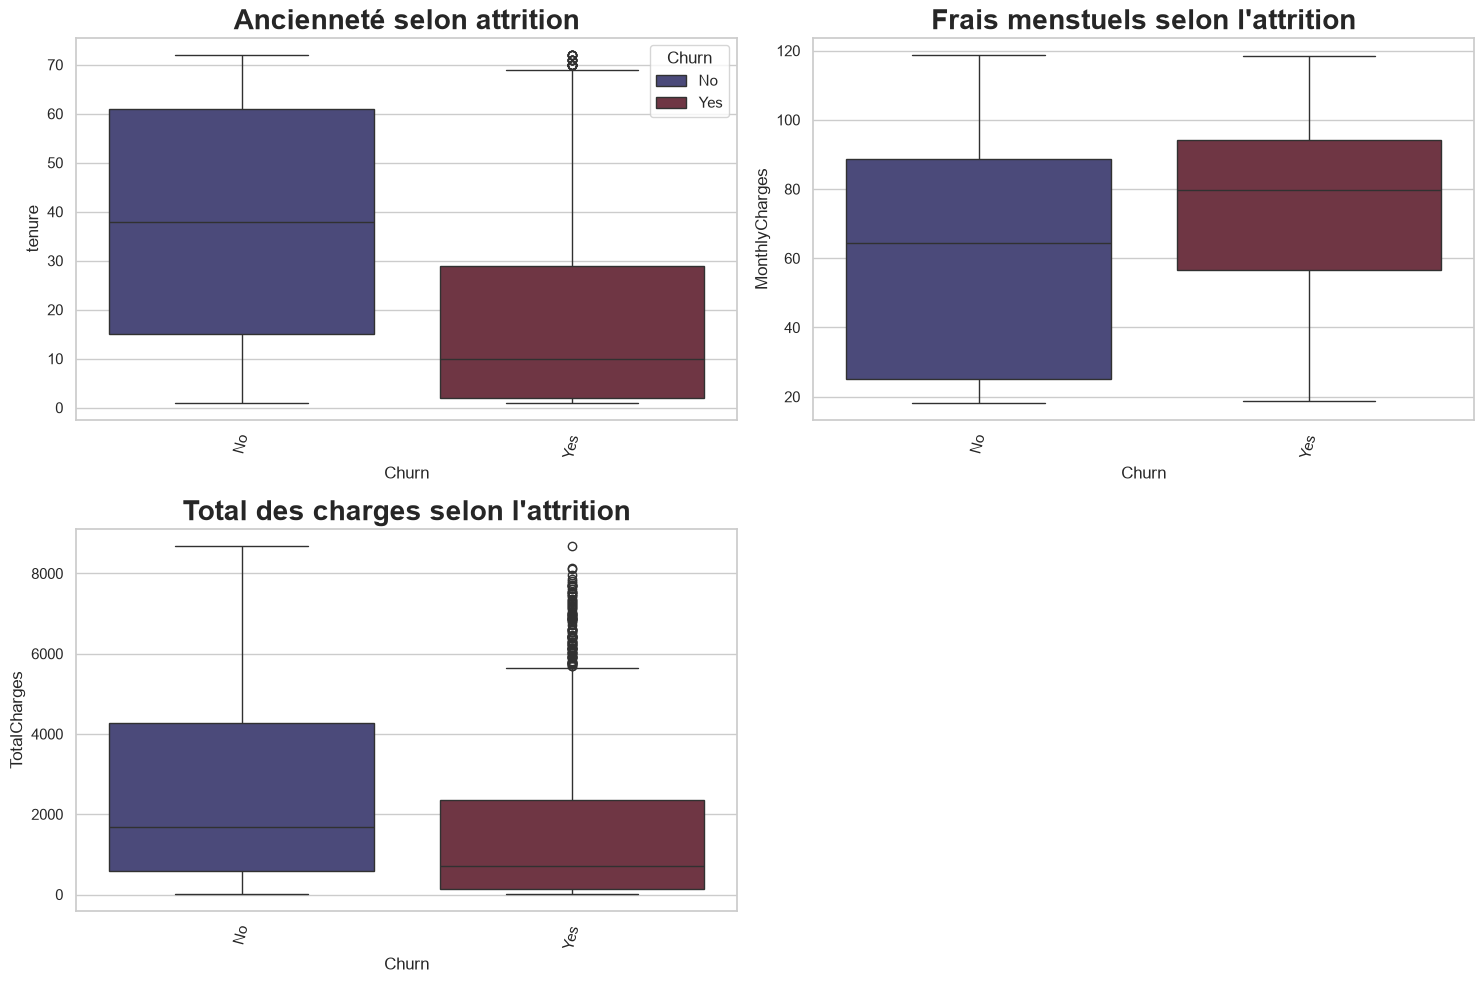

In [27]:
fig, axes=plt.subplots(2, 2, figsize=(15, 10))
ordre= ["No", "Yes"]

sns.boxplot(data=df, x="Churn", y="tenure", order=ordre ,hue="Churn", palette="icefire", legend= True,ax= axes[0, 0])
axes[0, 0].set_title("Ancienneté selon attrition",fontweight= 'bold', fontsize = '20')
axes[0, 0].tick_params(axis="x", rotation= 75)

sns.boxplot(data=df, x="Churn", y="MonthlyCharges", order=ordre ,hue="Churn", palette="icefire", legend= False,ax= axes[0, 1])
axes[0, 1].set_title("Frais menstuels selon l'attrition", fontweight= 'bold', fontsize = '20')
axes[0, 1].tick_params(axis="x", rotation= 75)

sns.boxplot(data=df, x="Churn", y="TotalCharges", order=ordre ,hue="Churn", palette="icefire", legend= False,ax= axes[1, 0])
axes[1, 0].set_title("Total des charges selon l'attrition",fontweight= 'bold', fontsize = '20')
axes[1, 0].tick_params(axis="x", rotation= 75)

fig.delaxes(axes[1, 1])

plt.tight_layout()
plt.show()

**Existe-t-il une corrélation entre les variables numériques ?**

<Axes: >

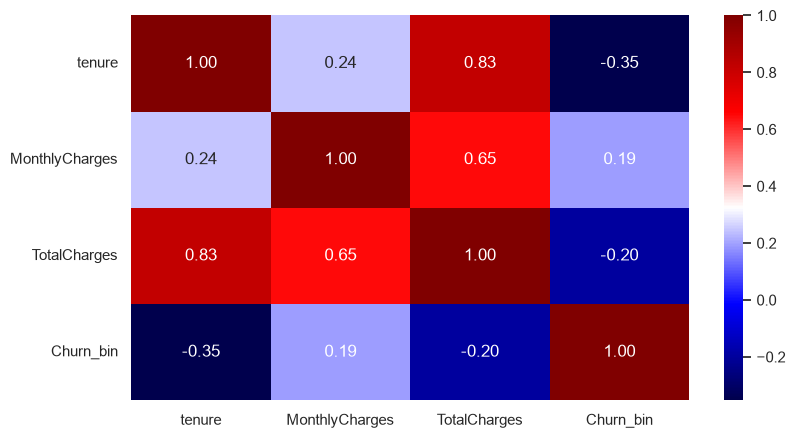

In [28]:
cor = df[["tenure", "MonthlyCharges","TotalCharges","Churn_bin"]].corr()
sns.heatmap(cor, annot=True, cmap="seismic", fmt=".2f")

# Commentaire Général : 



# IV- SEPARATION train / test — AVANT TOUT TRAITEMENT DEPENDANT DES STATISTIQUES

**séparer les variables explicatives de la cible, puis split train/test**

  **Le bout de code ci dessous sert à préparer les données pour un modèle de Machine Learning en séparant la variable cible (ce qu'on veut prédire) des variables **explicatives** (les caractéristiques), puis en divisant le tout en un `ensemble d'entrainement` et un `ensemble de test`**

In [29]:
X = df.drop(columns=["Churn", "Churn_bin"], errors = "ignore")
y = df["Churn"].map({"No": 0, "Yes": 1})

xtrain, xtest, ytrain, ytest = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train : {xtrain.shape}, Test : {xtest.shape}")
print(f"Répartition train : {ytrain.value_counts().to_dict()}")
print(f"Répartition test  : {ytest.value_counts().to_dict()}")

Train : (5608, 19), Test : (1402, 19)
Répartition train : {0: 4122, 1: 1486}
Répartition test  : {0: 1031, 1: 371}


In [30]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.preprocessing import FunctionTransformer

class Winsorizer(BaseEstimator, TransformerMixin):
    """Winsorise chaque colonne selon des bornes de percentile apprises sur le train (fit),
    puis appliquées telles quelles au transform — aucune statistique n'est recalculée sur le test."""
    def __init__(self, limits=(0.01, 0.01)):
        self.limits = limits

    def fit(self, x, y=None):
        X = np.asarray(x)
        low, high = self.limits
        self.lower_ = np.nanquantile(x, low, axis=0)
        self.upper_ = np.nanquantile(x, 1 - high, axis=0)
        # CORRECTION : mémorise le nombre de colonnes en entrée pour get_feature_names_out
        self.n_features_in_ = X.shape[1] if X.ndim > 1 else 1
        return self

    def transform(self, x):
        X = np.asarray(x).copy()
        return np.clip(x, self.lower_, self.upper_)

    def get_feature_names_out(self, input_features=None):
        if input_features is not None:
            return np.asarray(input_features, dtype=object)
        return np.asarray([f"x{i}" for i in range(self.n_features_in_)], dtype=object)


numeric_simple = ["MonthlyCharges"] # numérique propre
numeric_bounded = ["TotalCharges","tenure"]#numérique avec outliers
binary_cols = ["SeniorCitizen"]
nominal_cols = ["gender", "Partner", "Dependents", "InternetService", "Contract","PhoneService","MultipleLines","OnlineSecurity",
                "OnlineBackup","DeviceProtection","TechSupport","StreamingTV","PaperlessBilling","PaymentMethod","StreamingMovies"] # catégorielles

preprocessor = ColumnTransformer(transformers=[
    ("MonthlyCharges", StandardScaler(), numeric_simple),
    ("bounded", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("winsor", Winsorizer(limits=(0.01, 0.01))),
        ("log", FunctionTransformer(np.log1p, validate=True)),
        ("scale", StandardScaler()),
    ]), numeric_bounded),
    ("binary", "passthrough", binary_cols),
    ("nominal", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False), nominal_cols),
])

preprocessor


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('MonthlyCharges', ...), ('bounded', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` 

# 7) Gestion du déséquilibre — dans un pipeline de validation croisée sans fuite

### Q7.1 : comment rééquilibrer le train sans provoquer de fuite, y compris pendant la validation croisée ?

In [31]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import fbeta_score, make_scorer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN, SMOTETomek

f2_scorer = make_scorer(fbeta_score, beta=2)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

probe = RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=200)

strategies = {
    "aucun (class_weight=balanced)": None,
    "SMOTE": SMOTE(random_state=RANDOM_STATE),
    "SMOTEENN": SMOTEENN(random_state=RANDOM_STATE),
    "SMOTETomek": SMOTETomek(random_state=RANDOM_STATE),
}

resampling_results = {}
for name, resampler in strategies.items():
    steps = [("prep", preprocessor)]
    if resampler is not None:
        steps.append(("resample", resampler))
        clf = RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=200)
    else:
        clf = RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=200, class_weight="balanced")
    steps.append(("clf", clf))
    pipe = ImbPipeline(steps)
    scores = cross_val_score(pipe, xtrain, ytrain, cv=cv, scoring=f2_scorer, n_jobs= -1, error_score= "raise")
    resampling_results[name] = (scores.mean(), scores.std())
    print(f"{name:35s} F2 moyen = {scores.mean():.4f} (+/- {scores.std():.4f})")

aucun (class_weight=balanced)       F2 moyen = 0.6235 (+/- 0.0389)
SMOTE                               F2 moyen = 0.5749 (+/- 0.0438)
SMOTEENN                            F2 moyen = 0.7171 (+/- 0.0117)
SMOTETomek                          F2 moyen = 0.5781 (+/- 0.0441)


# Explication :

Ici, nous testons **les différentes stratégies de rééquilibrages des données :** afin de gérer le déséquilibre des `classes`(lorsqu'il y'a beaucoup plus de `No`que de `Yes`), sans fausser les résultats de la `validation croisée`. Dans le but de détecter les clients qui partent, La métrique  principale que nous avions misées est le `F2- Score` car il donne `deux fois plus d'importance au Recall qu'à la Précision`.

# Analyse des résultats affichés :

En observant les prints en bas, on peut comparer l'efficacité des **différentes méthodes** sur le **F2 moyen**. Ceci dit nous pouvons conclure que la combinaison `SMOTEENN`(qui sur-échantillonne la classe minoritaire puis nettoie le bruit) est la stratégie la `plus performante pour ce modèle`, car elle permet d'obtenir le meilleur compromis avec un **excellent rappel**

# VIII- COMPARAISONS DES MODELES (rappel : métrique de sélection = F2)

In [32]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=3000, random_state=RANDOM_STATE),
    "DecisionTree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    "GradientBoosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(),
    "SVC": SVC(probability=True, random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE),
}

model_results = {}
model_fold_scores = {}  # scores bruts par fold, nécessaires pour le test statistique ci-dessous
for name, clf in models.items():
    pipe = ImbPipeline([
        ("prep", preprocessor),
        ("resample", SMOTEENN(random_state=RANDOM_STATE)),
        ("clf", clf),
    ])
    scores = cross_val_score(pipe, xtrain, ytrain, cv=cv, scoring=f2_scorer, n_jobs=-1)
    model_results[name] = (scores.mean(), scores.std())
    model_fold_scores[name] = scores
    print(f"{name:20s} F2 moyen = {scores.mean():.4f} (+/- {scores.std():.4f})")

pd.DataFrame(model_results, index=["F2_moyen", "F2_std"]).T.sort_values("F2_moyen", ascending=False)


LogisticRegression   F2 moyen = 0.7456 (+/- 0.0076)
DecisionTree         F2 moyen = 0.6704 (+/- 0.0137)
RandomForest         F2 moyen = 0.7166 (+/- 0.0114)
GradientBoosting     F2 moyen = 0.7318 (+/- 0.0149)
KNN                  F2 moyen = 0.7223 (+/- 0.0046)
SVC                  F2 moyen = 0.7418 (+/- 0.0068)
XGBoost              F2 moyen = 0.7036 (+/- 0.0175)


,F2_moyen,F2_std
LogisticRegression,0.745564,0.007596
SVC,0.741813,0.006848
GradientBoosting,0.731839,0.014944
KNN,0.722253,0.004618
RandomForest,0.716616,0.011417
XGBoost,0.703649,0.017508
DecisionTree,0.670369,0.013682


# Explication:

Ce bout de code sert à **comparer différents algorithmes de Machine Learning** en utilisant la meilleure strategie de rééquilibrage trouvée précédemment (**SMOTEENN**) pour déterminer le modèle le plus performant. A la fin de l'exécution, les modèles sont triés du meilleur au moins bon selon leur **F2-Score**:

   **Le gagnant:** la `LogisticRegression` qui obtient le meilleur score avec un **F2_moyen de 0.7351**( suivie de très près par le `GradientBoosting` à **0.7338**).
    
   **Le moins performant:** Le `DecisionTree` est en retrait avec un score de **0.6858**

# Comparaison statistique formelle des modèles (le comité tranche : bruit ou vrai écart ?)

Les F2 moyens des meilleurs candidats sont séparés de quelques millièmes, un ordre de
grandeur comparable à l'écart-type inter-fold. Avant de désigner un "gagnant", le comité
vérifie si cet écart est statistiquement défendable via un **test de Wilcoxon apparié**
sur les scores fold-par-fold (le même `cv` — mêmes splits — est réutilisé pour tous les
modèles, ce qui rend la comparaison appariée légitime).


In [33]:
from scipy.stats import wilcoxon
from itertools import combinations

print("Test de Wilcoxon apparié (scores F2 par fold, mêmes splits StratifiedKFold pour tous les modèles)\n")

noms_tries = sorted(model_fold_scores, key=lambda n: -model_results[n][0])
top3 = noms_tries[:3]
print(f"Trois meilleurs modèles comparés : {top3}\n")

for m1, m2 in combinations(top3, 2):
    s1, s2 = model_fold_scores[m1], model_fold_scores[m2]
    stat, p = wilcoxon(s1, s2)
    diff = s1.mean() - s2.mean()
    signif = "significatif (p<0.05)" if p < 0.05 else "NON significatif (p>=0.05)"
    print(f"{m1:20s} vs {m2:20s} : diff F2 = {diff:+.4f} | p-value = {p:.4f} -> {signif}")

print("\nAVERTISSEMENT : avec cv=5 folds, le test de Wilcoxon dispose au maximum de 5 paires")
print("d'observations -> puissance statistique très limitée. Un résultat 'non significatif'")
print("ici ne prouve pas que les modèles sont équivalents, il signifie surtout qu'on ne peut")
print("PAS conclure à une différence avec les données disponibles. A lire comme un signal")
print("de prudence, pas comme une preuve formelle dans un sens ou dans l'autre.")


Test de Wilcoxon apparié (scores F2 par fold, mêmes splits StratifiedKFold pour tous les modèles)

Trois meilleurs modèles comparés : ['LogisticRegression', 'SVC', 'GradientBoosting']

LogisticRegression   vs SVC                  : diff F2 = +0.0038 | p-value = 0.6250 -> NON significatif (p>=0.05)
LogisticRegression   vs GradientBoosting     : diff F2 = +0.0137 | p-value = 0.1875 -> NON significatif (p>=0.05)
SVC                  vs GradientBoosting     : diff F2 = +0.0100 | p-value = 0.1250 -> NON significatif (p>=0.05)

AVERTISSEMENT : avec cv=5 folds, le test de Wilcoxon dispose au maximum de 5 paires
d'observations -> puissance statistique très limitée. Un résultat 'non significatif'
ici ne prouve pas que les modèles sont équivalents, il signifie surtout qu'on ne peut
PAS conclure à une différence avec les données disponibles. A lire comme un signal
de prudence, pas comme une preuve formelle dans un sens ou dans l'autre.


# IX- OPTIMISATION DES HYPER-PARAMETRES (`GridSearchCV`, scoring = F2)

In [34]:
import warnings
warnings.filterwarnings("ignore")

# --- LogisticRegression ---

pipe_lr = ImbPipeline([
    ("prep", preprocessor),
    ("resample", SMOTEENN(random_state=RANDOM_STATE)),
    
    # integration de la gestion du déséquilibre directement dans le modèle
    
    ("clf", LogisticRegression(max_iter=3000, random_state=RANDOM_STATE)),
        ])

    # Grille de recherche

grid_lr = {"clf__C": [0.01, 0.1, 1, 10]
           , "clf__penalty": ["l2"]}

gs_lr = GridSearchCV(pipe_lr, grid_lr, scoring=f2_scorer, cv=cv, n_jobs=-1)

gs_lr.fit(xtrain, ytrain)

print(f"LogisticRegression - meilleur F2 CV :{round(gs_lr.best_score_, 4)}")
print(f"Paramètres:{gs_lr.best_params_}")

# --- GradientBoosting ---

pipe_gb = ImbPipeline([
    ("prep", preprocessor),
    ("resample", SMOTEENN(random_state=RANDOM_STATE)),
    ("clf", GradientBoostingClassifier(random_state=RANDOM_STATE)),
])

    # Grille d'élargissement des meilleures performances

grid_gb = {"clf__n_estimators": [100, 200], 
           "clf__max_depth": [2, 3], 
           "clf__learning_rate": [0.01,0.05, 0.1]}

    # Calcul des poids pour contrebalancer le déséquilibre ddu (Churn)

gs_gb = GridSearchCV(pipe_gb, grid_gb, scoring=f2_scorer, cv=cv, n_jobs=-1)
 # Injection du poids directement dans l'entrainement du classifieur
gs_gb.fit(xtrain, ytrain)

print(f"GradientBoosting- meilleur F2 CV : { round(gs_gb.best_score_, 4)}")
print(f" Paramètres: {gs_gb.best_params_}")

# --- SVC ---

pipe_svc = ImbPipeline([
    ("prep", preprocessor),
    ("resample", SMOTEENN(random_state=RANDOM_STATE)),
    # Utilisation du class_weight = "balanced"
    ("clf", SVC(probability=True,class_weight = "balanced", random_state=RANDOM_STATE)),
])

grid_svc = {"clf__C": [0.1, 1, 10], 
            "clf__kernel": ["rbf","linear"]}

gs_svc = GridSearchCV(pipe_svc, grid_svc, scoring=f2_scorer, cv=cv, n_jobs=-1)
gs_svc.fit(xtrain, ytrain)

print(f"SVC - meilleur F2 CV : {round(gs_svc.best_score_, 4)}")
print(f" Paramètres:{gs_svc.best_params_}")

# --- XGBoost (ajouté à la comparaison) ---

pipe_xgb = ImbPipeline([
    ("prep", preprocessor),
    ("resample", SMOTEENN(random_state=RANDOM_STATE)),
    ("clf", XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE)),
])

grid_xgb = {"clf__n_estimators": [100, 200],
            "clf__max_depth": [2, 3, 4],
            "clf__learning_rate": [0.01, 0.05, 0.1]}

gs_xgb = GridSearchCV(pipe_xgb, grid_xgb, scoring=f2_scorer, cv=cv, n_jobs=-1)
gs_xgb.fit(xtrain, ytrain)

print(f"XGBoost - meilleur F2 CV : {round(gs_xgb.best_score_, 4)}")
print(f" Paramètres:{gs_xgb.best_params_}")

candidates = {"LogisticRegression": gs_lr,
              "GradientBoosting": gs_gb, 
              "SVC": gs_svc,
              "XGBoost": gs_xgb,}

best_name = max(candidates, key=lambda k: candidates[k].best_score_)
best_search = candidates[best_name]

print(f"\n>>> Modèle retenu globalement: {best_name} (F2 CV = {best_search.best_score_:.4f})")
print(f" Meilleurs hyperparamètres:{best_search.best_params_}")

# Extraction du meilleur estimateur
best_est = best_search.best_estimator_


LogisticRegression - meilleur F2 CV :0.7484
Paramètres:{'clf__C': 0.01, 'clf__penalty': 'l2'}
GradientBoosting- meilleur F2 CV : 0.7444
 Paramètres: {'clf__learning_rate': 0.01, 'clf__max_depth': 3, 'clf__n_estimators': 200}
SVC - meilleur F2 CV : 0.745
 Paramètres:{'clf__C': 10, 'clf__kernel': 'linear'}
XGBoost - meilleur F2 CV : 0.7458
 Paramètres:{'clf__learning_rate': 0.01, 'clf__max_depth': 3, 'clf__n_estimators': 100}

>>> Modèle retenu globalement: LogisticRegression (F2 CV = 0.7484)
 Meilleurs hyperparamètres:{'clf__C': 0.01, 'clf__penalty': 'l2'}


° Ici, ce code applique exactement la même logique d'optimisation que l'étape précédente, mais cette fois-ci pour le modèle `Gradient Boosting`. Deplus, il permet de trouver les **meilleurs réglages (hyperparamètres)** pour la `Regression Logistique` afin de maximiser sa capacité à détecter les **départs de clients**, d'où l'utilisation de la **Recherche par Grille** appelée `GridSearchCV`.

# X- EVALUATION FINALE SUR LE JEU DE TEST

**Correction appliquée ici (par rapport à la version précédente) :**

Le bug qui figeait le score F2 à sa valeur au seuil 0.5 pendant toute la boucle de
recherche (variable `yprep_ajuste` calculée mais jamais réinjectée dans le calcul du
score) est corrigé : à chaque seuil testé, le F2 est maintenant recalculé sur la bonne
prédiction (`ypred_ajuste` mis à jour dans la boucle).


In [35]:
#--- Cellule de diagnostic ---
# Extraction brute des probabilités du modèle retenu
yproba_diagnostic = best_est.predict_proba(xtest)[:, 1]

print("--- ANALYSE TECHNIQUE DES PROBABILITES PREDITES ---")
print(f"Nombre total de lignes évaluées : {len(yproba_diagnostic)}")
print(f"Valeurs minimales prédites : {yproba_diagnostic.min():.4f}")
print(f"Valeurs maximales prédites : {yproba_diagnostic.max():.4f}")
print(f"Moyenne des probabilités : {yproba_diagnostic.mean():.4f}")

print("\n Affichage des 15 premières probabilités du vecteur : ")
print(np.round(yproba_diagnostic[:15], 4))



--- ANALYSE TECHNIQUE DES PROBABILITES PREDITES ---
Nombre total de lignes évaluées : 1402
Valeurs minimales prédites : 0.0074
Valeurs maximales prédites : 0.9958
Moyenne des probabilités : 0.4938

 Affichage des 15 premières probabilités du vecteur : 
[0.8213 0.0804 0.4321 0.6429 0.8321 0.9183 0.4503 0.3729 0.6143 0.5636
 0.8192 0.1258 0.4602 0.9368 0.989 ]


In [36]:
from sklearn.metrics import roc_auc_score, average_precision_score

seuil_possibles = np.linspace(0.49, 0.95, 91)
meilleur_seuil = 0.5
meilleur_f2 = 0
yproba = best_est.predict_proba(xtest)[:, 1] 

for seuil in seuil_possibles:
    ypred_ajuste = (yproba >= seuil).astype(int)   # <- CORRECTION : recalculé à chaque itération
    score_f2_temp = fbeta_score(ytest, ypred_ajuste, beta=2)
    if score_f2_temp > meilleur_f2:
        meilleur_f2 = score_f2_temp
        meilleur_seuil = seuil
best_est = best_search.best_estimator_
best_est.fit(xtrain, ytrain)

print(f"Seuil optimal trouvé : {meilleur_seuil:.2f}")
print(f"F2 maximal atteint   : {meilleur_f2:.4f}")

ypred = (yproba >= meilleur_seuil).astype(int)

print("\n--- Rapport de classification (seuil optimisé) ---")
print(classification_report(ytest, ypred, digits=3, target_names=["No Churn", "Churn"]))

metrics_summary = {
    "seuil_utilise": float(meilleur_seuil),
    "F2": fbeta_score(ytest, ypred, beta=2),
    "Rappel": recall_score(ytest, ypred),
    "Précision": precision_score(ytest, ypred),
    "F1": f1_score(ytest, ypred),
    "ROC-AUC": roc_auc_score(ytest, yproba),
    "PR-AUC": average_precision_score(ytest, yproba),
}
for k, v in metrics_summary.items():
    print(f"{k:15s}: {v:.4f}" if isinstance(v, float) else f"{k:15s}: {v}")


Seuil optimal trouvé : 0.50
F2 maximal atteint   : 0.7527

--- Rapport de classification (seuil optimisé) ---
              precision    recall  f1-score   support

    No Churn      0.941     0.633     0.757      1031
       Churn      0.466     0.889     0.612       371

    accuracy                          0.701      1402
   macro avg      0.704     0.761     0.684      1402
weighted avg      0.815     0.701     0.719      1402

seuil_utilise  : 0.5002
F2             : 0.7527
Rappel         : 0.8895
Précision      : 0.4661
F1             : 0.6117
ROC-AUC        : 0.8441
PR-AUC         : 0.6395


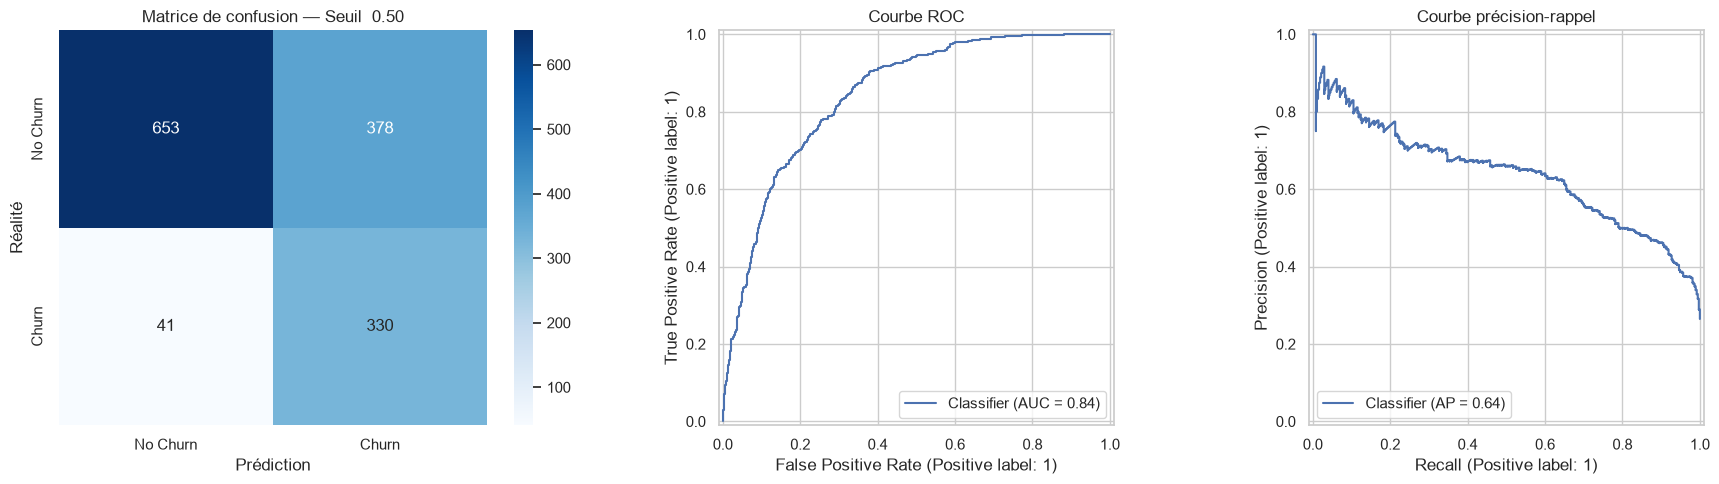

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Matrice de confusion
cm = confusion_matrix(ytest, ypred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"], ax=axes[0])
axes[0].set_xlabel("Prédiction")
axes[0].set_ylabel("Réalité")
axes[0].set_title(f"Matrice de confusion — Seuil {meilleur_seuil : .2f}")

# Courbe ROC
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay
RocCurveDisplay.from_predictions(ytest, yproba, ax=axes[1])
axes[1].set_title("Courbe ROC")

# Courbe précision-rappel
PrecisionRecallDisplay.from_predictions(ytest, yproba, ax=axes[2])
axes[2].set_title("Courbe précision-rappel")

plt.tight_layout()
plt.show()

# X-bis - SEUIL ALTERNATIF : OPTIMISATION PAR COUT METIER (avis du comité business)

Le F2-Score (beta=2) est une approximation statistique de l'idée "rater un churner coûte
plus cher qu'un faux positif" — mais le facteur 2 est une convention, pas un chiffre dérivé
de coûts réels de l'entreprise. Le comité recommande de compléter (et à terme remplacer)
le seuil F2 par un seuil dérivé d'une **matrice de coût explicite** :

- **Coût d'un faux négatif** (churner manqué, non contacté) : perte de revenu estimée
  = `MonthlyCharges` du client × horizon de rétention.
- **Coût d'un faux positif** (client contacté inutilement) : coût opérationnel fixe d'une
  action de rétention (centre d'appel, offre promotionnelle...).

**Les valeurs ci-dessous (20 unités monétaires / contact, horizon de 12 mois) sont des
hypothèses illustratives — à remplacer impérativement par les vrais chiffres de
l'entreprise (LTV moyenne réelle, coût réel d'une campagne de rétention, taux de succès
des relances) avant tout déploiement en production.**


**Lecture du comité :** ce seuil coût-optimal n'a aucune raison de coïncider avec le seuil
F2 — il dépend entièrement des hypothèses de coût saisies ci-dessus (`COUT_CONTACT_INUTILE`,
`HORIZON_MOIS_PERTE`). Une fois les vrais montants de l'entreprise injectés, c'est **cette
version**, alignée sur l'impact financier réel, qui doit servir de base à la décision de
seuil en production — le F2 reste utile comme métrique de sélection de modèle en amont,
mais ne doit pas dicter seul le seuil final de mise en production.


In [38]:
import json

os.makedirs("../model_artifacts", exist_ok=True)

joblib.dump(best_est, "../model_artifacts/Churn_model_pipeline.joblib")

metadata = {
    "modele": best_name,
    "hyperparametres": best_search.best_params_,
    "resampling": "SMOTEENN",
    "metrique_selection": "F2 (beta=2)",
    "f2_cv": float(best_search.best_score_),
    "seuil_decision": float(meilleur_seuil),
    "metriques_test": {k: float(v) for k, v in metrics_summary.items()},
}
with open("../model_artifacts/Churn_model_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print("Pipeline complet (prétraitement + rééquilibrage + modèle) sauvegardé.")
print(f"Seuil de décision (optimisé F2) : {meilleur_seuil:.2f}")
print("(le pipeline seul, via .predict(), utilise 0.5 par défaut — appliquer le seuil")
print(" choisi manuellement sur best_est.predict_proba(X)[:, 1] >= seuil en production)")
print(json.dumps(metadata, indent=2, ensure_ascii=False))

Pipeline complet (prétraitement + rééquilibrage + modèle) sauvegardé.
Seuil de décision (optimisé F2) : 0.50
(le pipeline seul, via .predict(), utilise 0.5 par défaut — appliquer le seuil
 choisi manuellement sur best_est.predict_proba(X)[:, 1] >= seuil en production)
{
  "modele": "LogisticRegression",
  "hyperparametres": {
    "clf__C": 0.01,
    "clf__penalty": "l2"
  },
  "resampling": "SMOTEENN",
  "metrique_selection": "F2 (beta=2)",
  "f2_cv": 0.7483941075863997,
  "seuil_decision": 0.5002222222222222,
  "metriques_test": {
    "seuil_utilise": 0.5002222222222222,
    "F2": 0.7527372262773723,
    "Rappel": 0.889487870619946,
    "Précision": 0.4661016949152542,
    "F1": 0.6116774791473587,
    "ROC-AUC": 0.8441049827320714,
    "PR-AUC": 0.6395096823663257
  }
}
